# Predictive Modeling with Linear Regression Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.

### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.

### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [85]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Function to calculate VIF
def checking_vif(dataframe):
    vif = pd.DataFrame()
    vif["feature"] = dataframe.columns
    vif["VIF"] = [variance_inflation_factor(dataframe.values, i)
                  for i in range(dataframe.shape[1])]
    return vif.sort_values(by="VIF", ascending=False)



# Function to evaluate model performance
def model_performance_regression(model, X_train, y_train):
    y_pred_train = model.predict(X_train)
    scores = {"RMSE":np.sqrt(mean_squared_error(y_train,y_pred_train)),
                "MAE":mean_absolute_error(y_train,y_pred_train),
                "R-squared":r2_score(y_train,y_pred_train),
                "Adj. R-squared":1 - (1-r2_score(y_train,y_pred_train))*(len(y_train)-1)/(len(y_train)-X_train.shape[1]-1),
                "MAPE":np.mean(np.abs((y_train-y_pred_train)/y_train))*100}

    return pd.DataFrame(scores, index=[0])


# Objective

The used electronics market is growing rapidly and pricing
is highly inconsistent across devices.

 We are going to build a regression model to predict

  * normalized used price and
 * identify key price drivers.


## Loading the dataset

In [ ]:
df = pd.read_csv("used_device_data.csv")
df.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [ ]:
df.tail()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3449,Asus,Android,15.34,yes,no,NaN,8.0,64.0,6.0,5000.0,190.0,2019,232,4.492337,6.483872
3450,Asus,Android,15.24,yes,no,13.0,8.0,128.0,8.0,4000.0,200.0,2018,541,5.037732,6.251538
3451,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,3.0,4000.0,165.0,2020,201,4.357350,4.528829
3452,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,2.0,4000.0,160.0,2020,149,4.349762,4.624188
3453,Alcatel,Android,12.83,yes,no,13.0,5.0,16.0,2.0,4000.0,168.0,2020,176,4.132122,4.279994


## Data Overview

- Observations
- Sanity checks

In [ ]:
df.shape

(3454, 15)




3454 rows (devices)
15 columns (features)

In [ ]:
df.columns

Index(['brand_name', 'os', 'screen_size', '4g', '5g', 'main_camera_mp',
       'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight',
       'release_year', 'days_used', 'normalized_used_price',
       'normalized_new_price'],
      dtype='object')


 list of all columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

We identified several categorical variables stored as object data types, including:

brand_name

os

4g

5g

These variables cannot be directly used in linear regression models and therefore will later be converted into numerical dummy variables using One-Hot Encoding.

The remaining variables are already numerical.

In [ ]:
df.describe()

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841



 sStatistical summary show: mean, std, min, max

## OBSERVATIONS

The dataset contains both numerical and categorical variables.

### Observation 2

The target variable is normalized_used_price.


### Observation 3

Some variables like brand_name and os are categorical.

### Observation 4

Features such as RAM, battery, and camera are numerical.

## 6.  SANITY CHECKS

In [ ]:
df.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


MISSING VALUES HANDLING

Missing values are handled using median imputation
because it is robust to outliers.




In [ ]:
num_cols = [
    'main_camera_mp',
    'selfie_camera_mp',
    'int_memory',
    'ram',
    'battery',
    'weight'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

We fill missing values with median.

### CHECK AFTER IMPUTATION


In [ ]:
df.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,0
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


## TARGET VARIABLE CHECK

Ensure target variable has no missing values and is numeric

In [ ]:
df['normalized_used_price'].describe()

,normalized_used_price
count,3454.000000
mean,4.364712
std,0.588914
min,1.536867
25%,4.033931
50%,4.405133
75%,4.755700
max,6.619433


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

## 1 — Univariate Analysis

It is useful for:

detecting skewness

identifying outliers

understanding feature ranges

discovering dominant categories

We begin by analyzing numerical and categorical variables separately.

### Distribution of Numerical Features

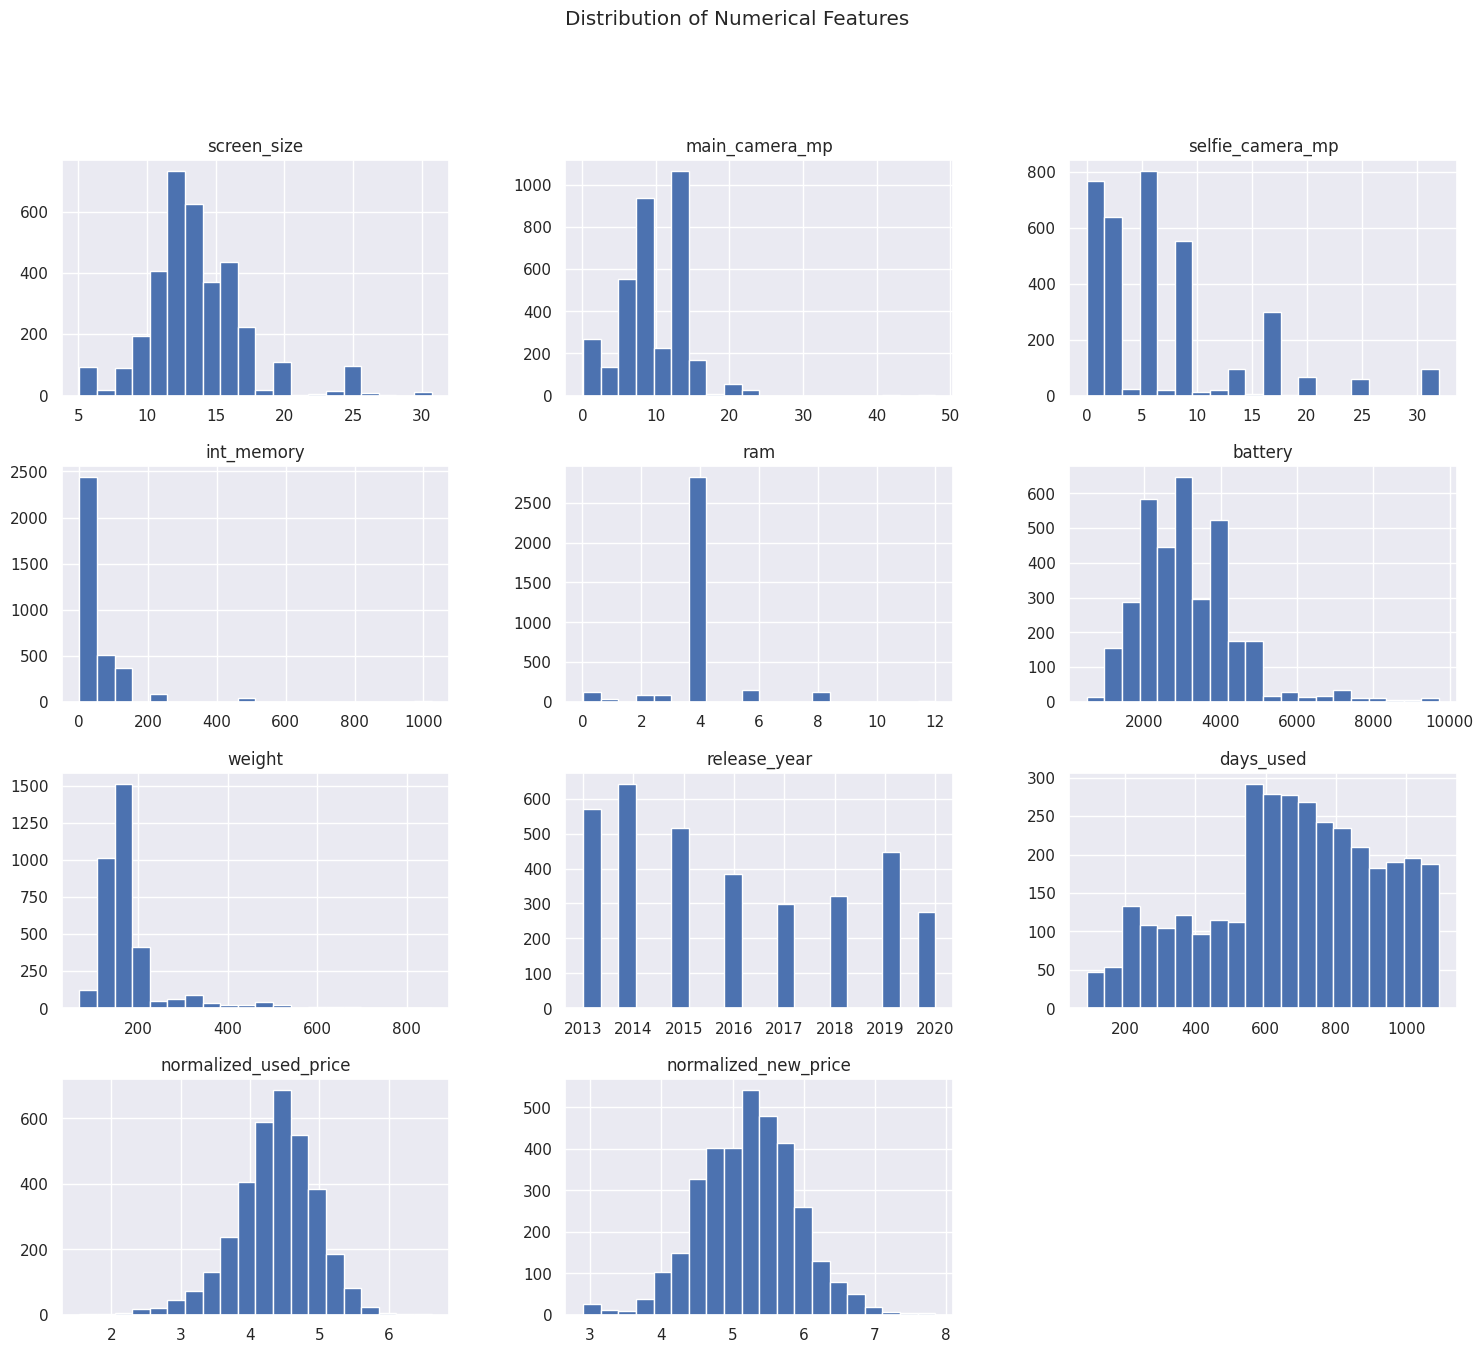

In [ ]:
# Selecting numerical columns

num_cols = df.select_dtypes(include=np.number).columns

# Histograms for numerical features

df[num_cols].hist(
    figsize=(18, 15),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")

plt.show()

Several numerical variables appear right-skewed, especially price-related variables.

RAM, battery, and camera specifications vary significantly across devices.

Some variables contain potential outliers, particularly:

* battery

* normalized_new_price

* normalized_used_price

Most devices belong to the mid-range specification category.

### Boxplots for Outlier Detection

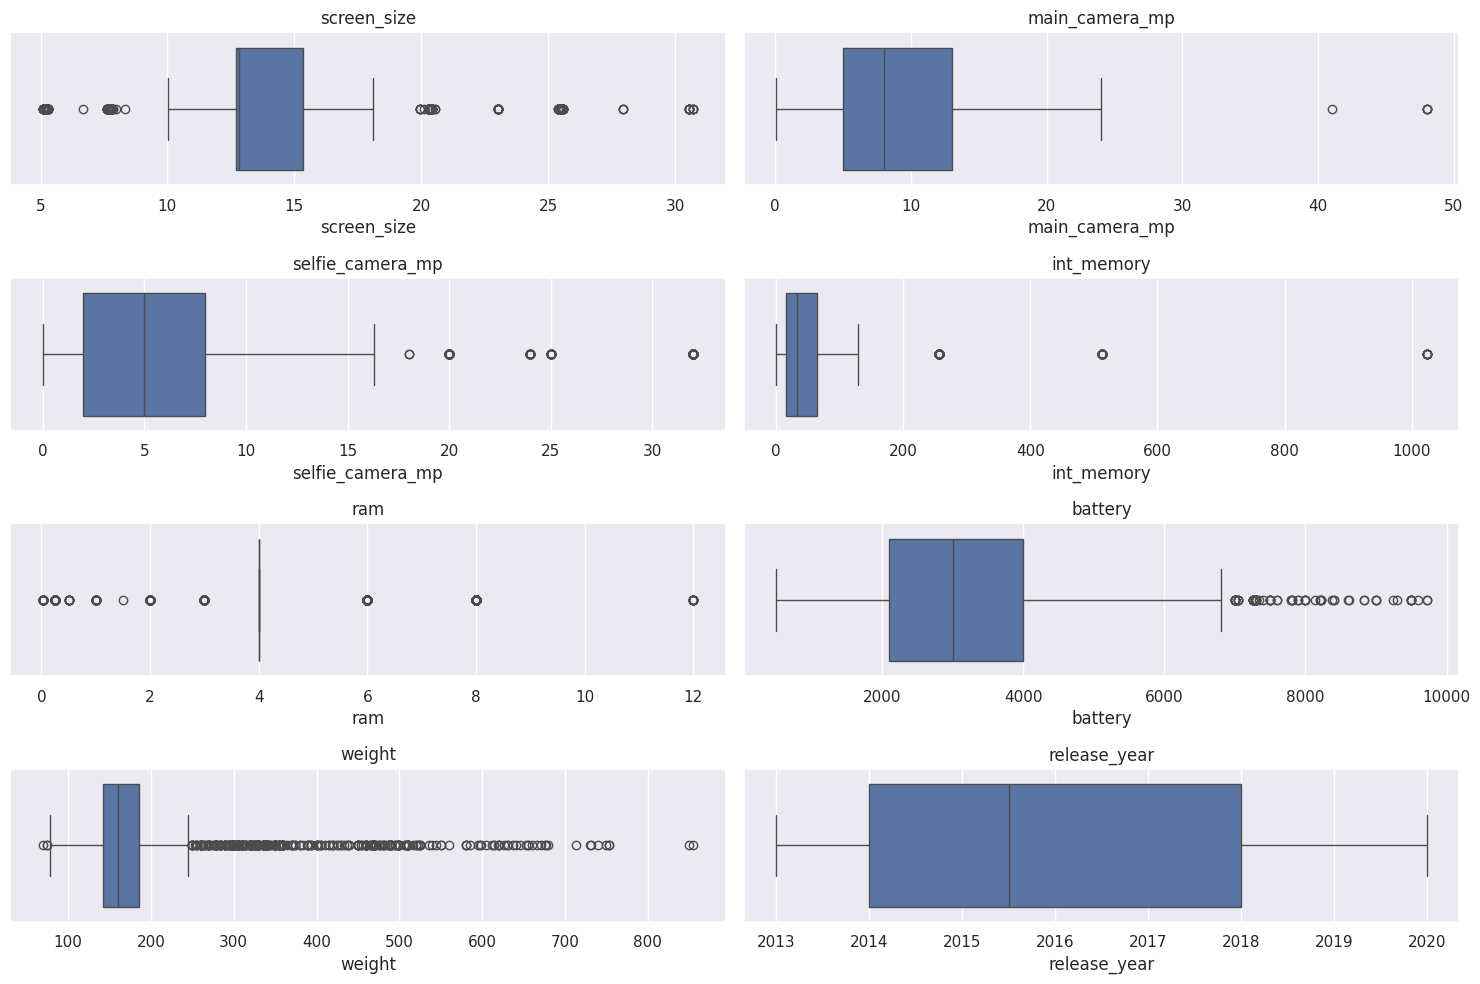

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols[:8], 1):

    plt.subplot(4,2,i)

    sns.boxplot(x=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

Outliers are present in several hardware-related features.

Premium flagship devices contribute to extremely high values in:

* RAM

* camera quality

* price

These outliers may influence linear regression performance.

### Categorical Variable Analysis

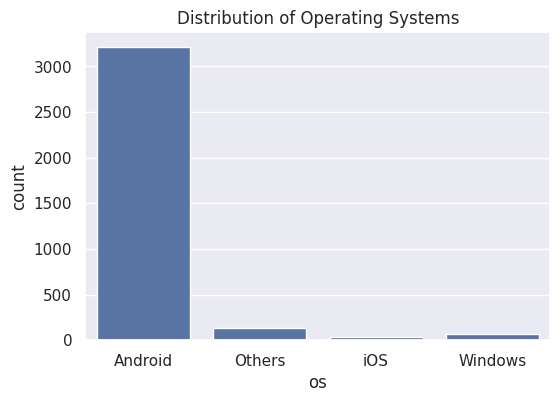

In [ ]:
# Operating System distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x='os')

plt.title("Distribution of Operating Systems")

plt.show()

* Android devices dominate the dataset.

* iOS devices represent a smaller portion of the market but are generally positioned in the premium category.

### Brand Distribution

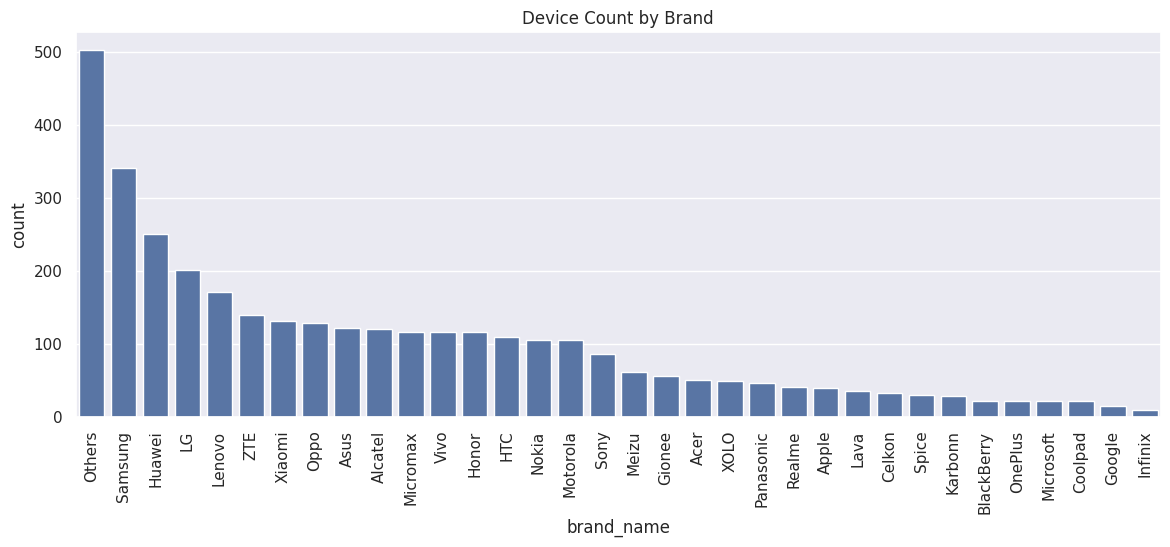

In [ ]:
plt.figure(figsize=(14,5))

sns.countplot(
    data=df,
    x='brand_name',
    order=df['brand_name'].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Device Count by Brand")

plt.show()

Samsung, Xiaomi, LG, Lenovo, and Huawei appear most frequently.

The dataset is heavily concentrated around Android manufacturers.

Smaller brands have fewer observations, which may affect model generalization.

## 2 — Bivariate Analysis

This analysis is especially important for identifying:


* relationships with target variable

* feature interactions

* trends and dependencies

These insights help improve feature selection and model performance.

## RAM vs Used Device Price

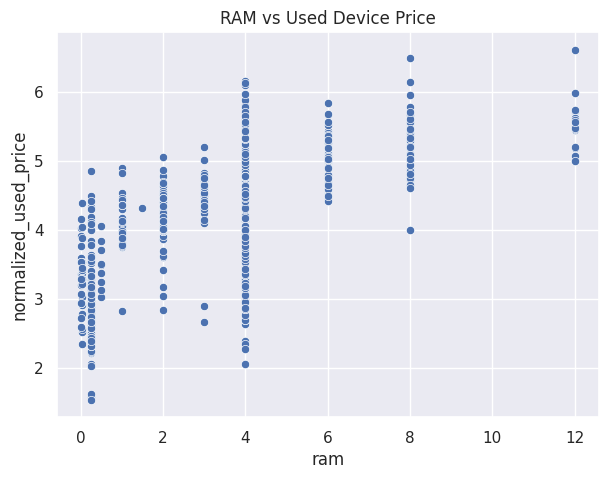

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='ram',
    y='normalized_used_price'
)

plt.title("RAM vs Used Device Price")

plt.show()

Devices with larger RAM generally have higher resale prices.

Higher RAM is strongly associated with premium devices.

RAM appears to be an important predictor for price estimation.

### Battery vs Price

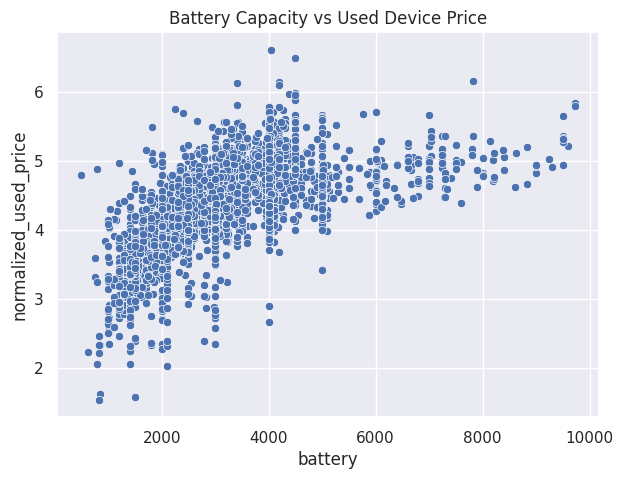

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='battery',
    y='normalized_used_price'
)

plt.title("Battery Capacity vs Used Device Price")

plt.show()

Devices with larger batteries tend to have higher resale prices.

Premium devices often combine:

* large battery

* strong hardware

* modern specifications

### Release Year vs Price

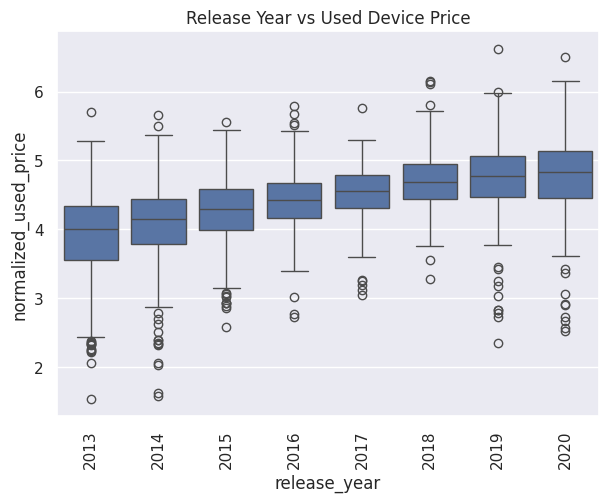

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='release_year',
    y='normalized_used_price'
)

plt.xticks(rotation=90)

plt.title("Release Year vs Used Device Price")

plt.show()

Newer devices retain significantly higher resale value.

Older devices show stronger price depreciation.

Device age plays an important role in used market pricing.

### Price Distribution Across Operating Systems

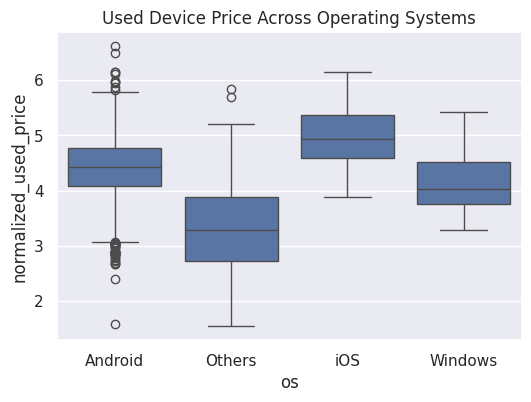

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x='os',
    y='normalized_used_price'
)

plt.title("Used Device Price Across Operating Systems")

plt.show()

iOS devices generally maintain higher resale prices.

Android devices cover a broader price range.

Apple devices demonstrate stronger value retention in the secondary market.

### Correlation Pairplot

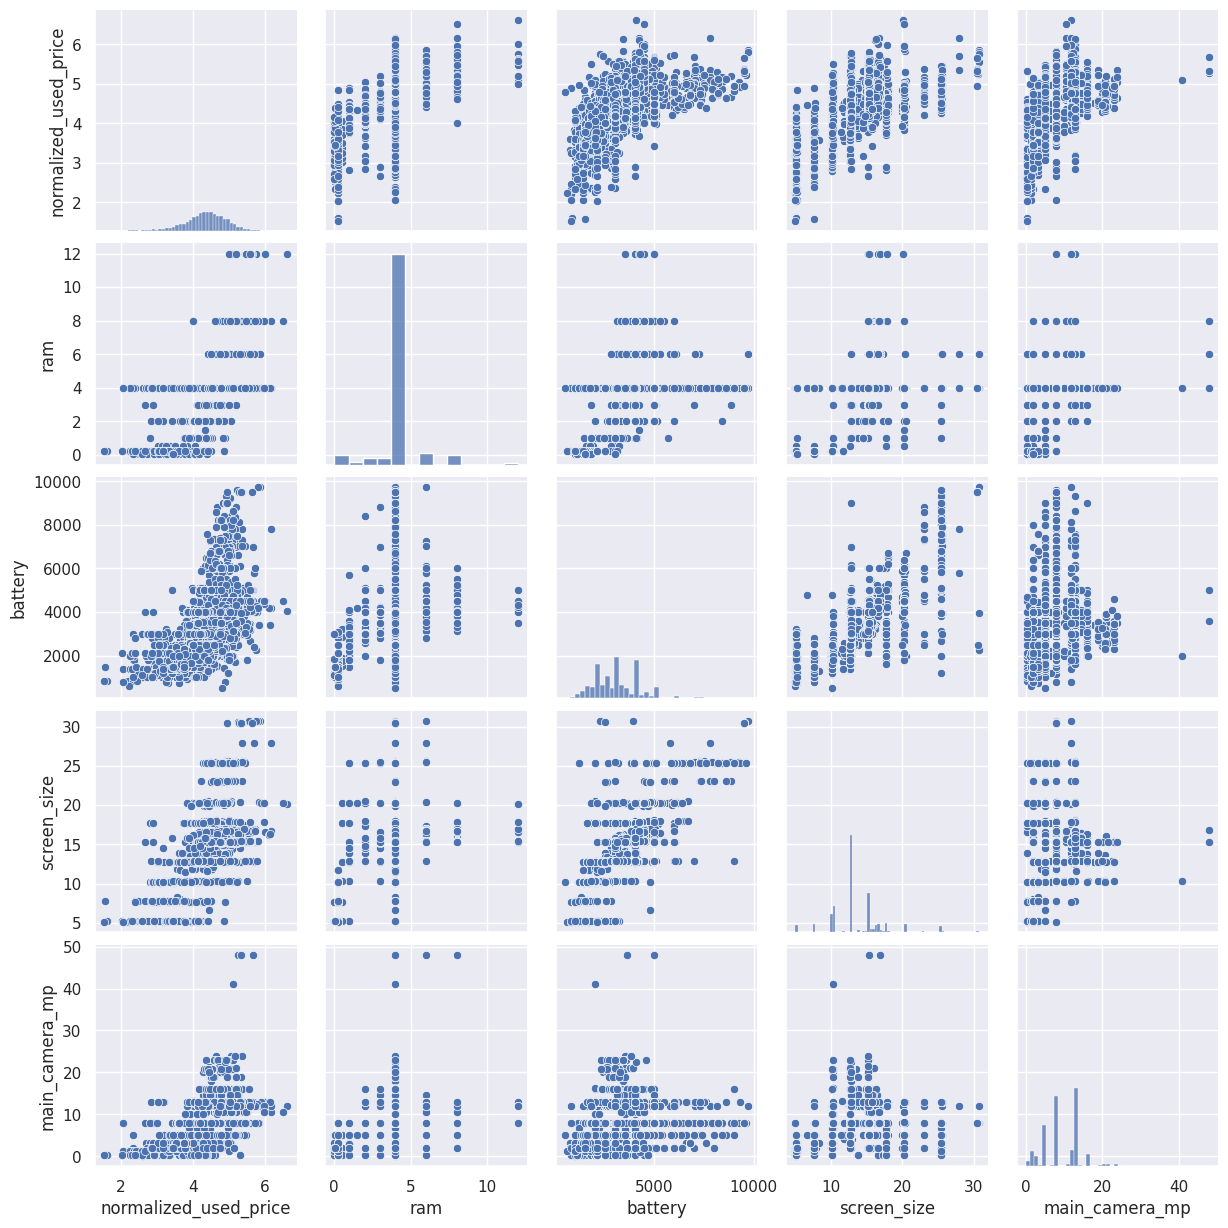

In [ ]:
selected_cols = [
    'normalized_used_price',
    'ram',
    'battery',
    'screen_size',
    'main_camera_mp'
]

sns.pairplot(df[selected_cols])

plt.show()

Several hardware specifications show positive relationships with price.

RAM and camera quality demonstrate stronger linear relationships.

Some variables exhibit multicollinearity, which should be considered during regression modeling.

**Questions**:

1. What does the distribution of normalized used device prices look like?
2. What percentage of the used device market is dominated by Android devices?
3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

# Question 1: What does the distribution of normalized used device prices look like?

## Distribution of normalized device prices

We use a histogram with KDE (Kernel Density Estimation) to analyze how used device prices are distributed.

* Histogram shows frequency distribution

* KDE curve shows the smoothed density of the data

* This helps identify skewness and concentration of prices

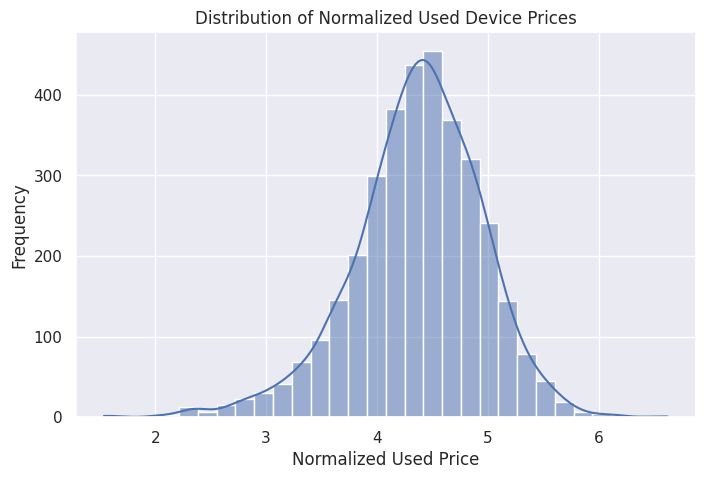

In [ ]:
# Plotting the distribution of used device prices

plt.figure(figsize=(8,5))

sns.histplot(
    df['normalized_used_price'],
    bins=30,
    kde=True
)

plt.title("Distribution of Normalized Used Device Prices")
plt.xlabel("Normalized Used Price")
plt.ylabel("Frequency")

plt.show()

## Insights

* Most used devices fall into the mid-price segment.

* The distribution appears left-skewed, meaning there are fewer expensive devices.

* Premium devices exist, but they represent a fewer portion of the market.

# Question 2: What percentage of the used device market is dominated by Android devices?

##  Android market share

We calculate the percentage of Android devices in the dataset.

shape[0] returns the number of rows.

**Formula:**

* Android Devices / Total Devices × 100


In [ ]:
# Calculating Android market share

android_share = (
    df[df['os'] == 'Android'].shape[0]
    / df.shape[0]
) * 100

print(f"Android Market Share: {android_share:.2f}%")

Android Market Share: 93.05%



* Android dominates the used device market with more than 93% share.

* This indicates a highly Android-centric resale market.

* Although iOS devices are fewer, they typically belong to the premium segment.


# Question 3: How does RAM vary across brands?

## RAM Distribution by Brand

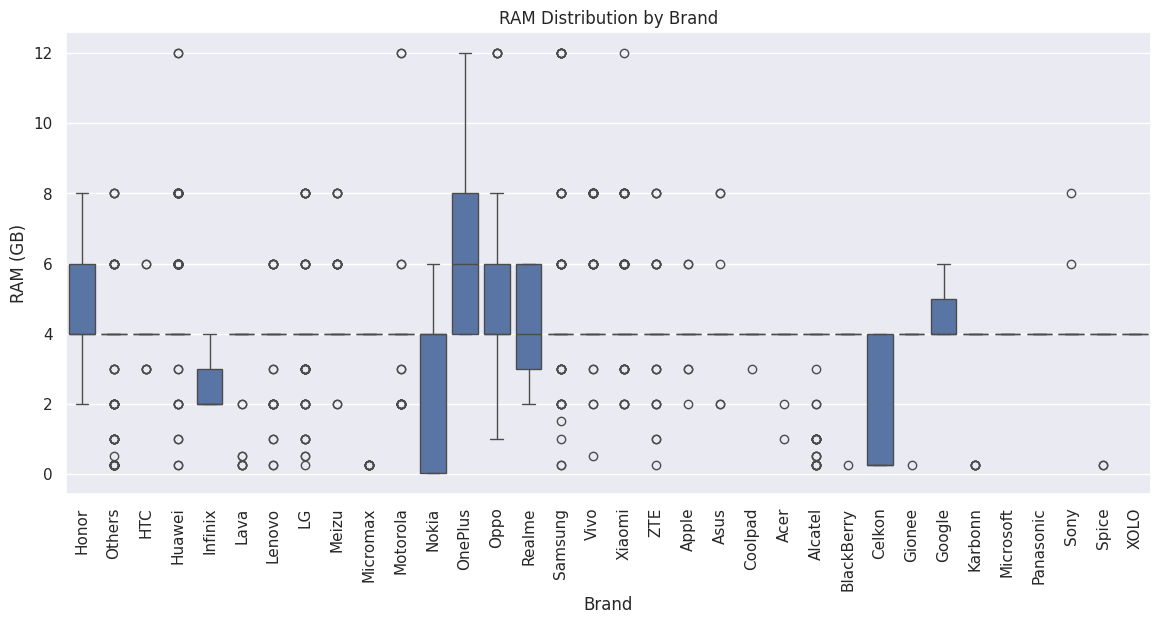

In [ ]:
# Comparing RAM distribution across brands

plt.figure(figsize=(14,6))

sns.boxplot(
    x='brand_name',
    y='ram',
    data=df
)

plt.xticks(rotation=90)

plt.title("RAM Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("RAM (GB)")

plt.show()


* Premium brands generally provide higher RAM capacity.

* Brands such as OnePlus, Oppo, Vivo, Google, and Samsung tend to offer devices with larger RAM.

* Budget brands show lower median RAM and greater variability.

# Question 4: How does weight vary for devices with batteries larger than 4500 mAh?

##  Battery vs Weight (>4500 mAh)

**Large batteries usually increase device weight.**



In [ ]:
# Filtering devices with battery > 4500 mAh

df_large_battery = df[df['battery'] > 4500]

print(df_large_battery.shape)

(341, 15)


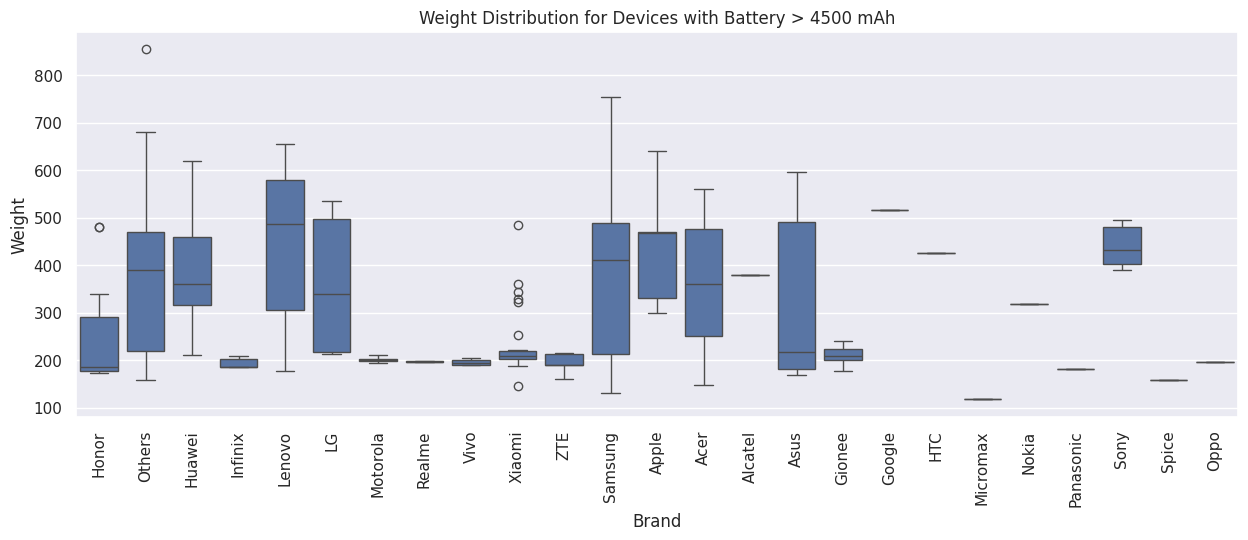

In [ ]:
# Boxplot for weight distribution

plt.figure(figsize=(15,5))

sns.boxplot(
    x='brand_name',
    y='weight',
    data=df_large_battery
)

plt.xticks(rotation=90)

plt.title("Weight Distribution for Devices with Battery > 4500 mAh")
plt.xlabel("Brand")
plt.ylabel("Weight")

plt.show()


* Devices with large batteries tend to be heavier (Lenovo, LG, Sumsung, Apple,Asus, Sony, Huawai).

* Some brands ( Samsung, Lenovo, Aser, Asus, LG) show:

a wide weight distribution, they offer both **lighter and heavier models.**

* A few brands manage to keep devices  lightweight (around 200)  even with large batteries(as Xaomi,  Infinix, Gionee) suggesting better structural optimization.

**Devices with batteries above 4500 mAh are generally heavier**, but the extent of weight increase varies **by brand.**

**Some manufacturers optimize weight better.**

# Question 5: How many devices have screens larger than 6 inches across brands?

## Screen Size Analysis

Large screens improve entertainment experience.


(3362, 15)


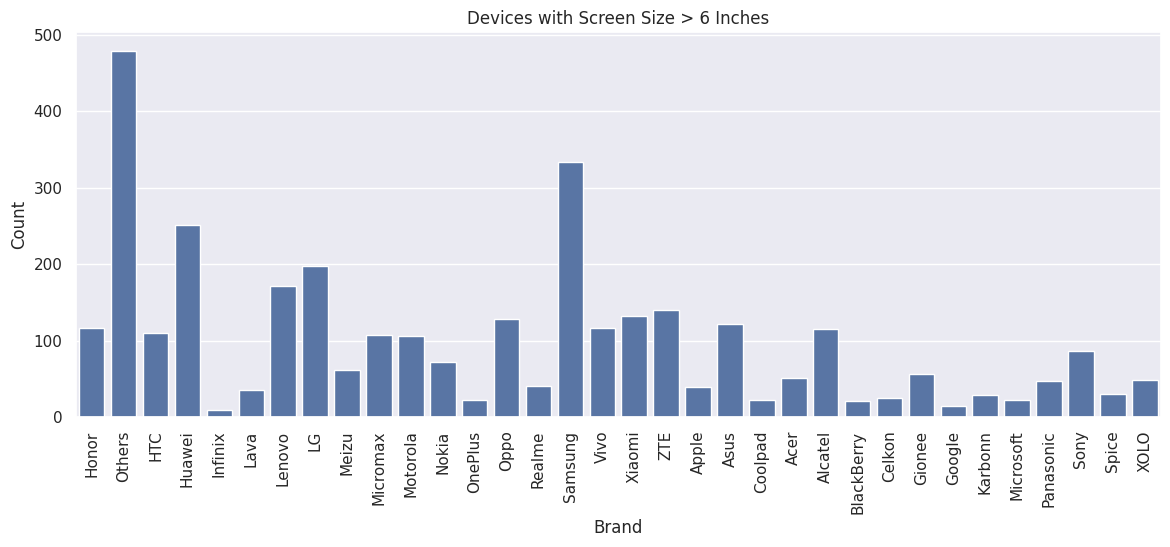

In [ ]:
# Devices with screen size > 6 inches

large_screen = df[df['screen_size'] > 6]

print(large_screen.shape)

# Countplot

plt.figure(figsize=(14,5))

sns.countplot(
    x='brand_name',
    data=large_screen
)

plt.xticks(rotation=90)

plt.title("Devices with Screen Size > 6 Inches")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.show()


* Samsung, Xiaomi, Huawei, and Realme offer many large-screen devices.

* Brands targeting entertainment users prioritize bigger screens.


# Question 6: What is the distribution of devices with selfie cameras greater than 8MP across brands?

## Selfie Camera Analysis

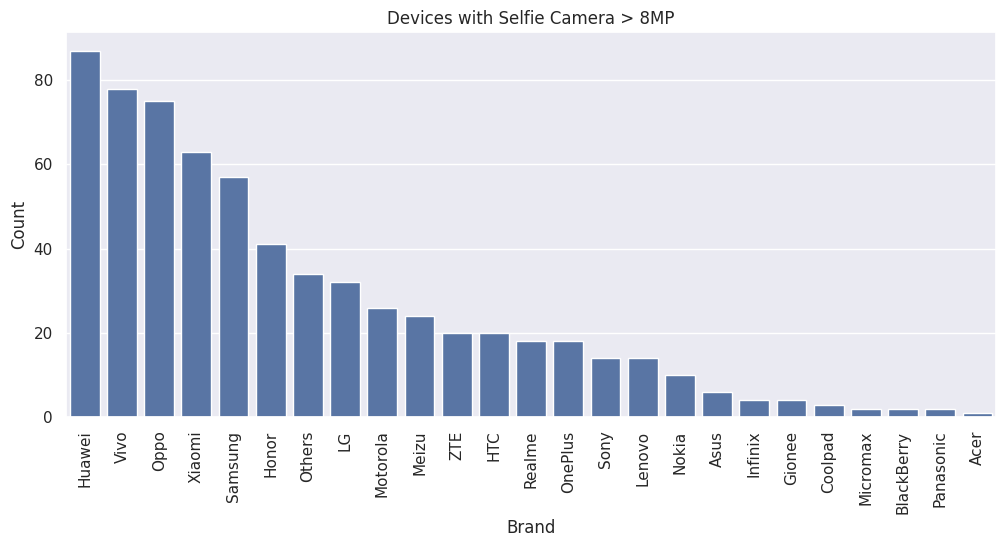

In [ ]:
# Filtering devices with selfie camera > 8MP

selfie = df[df['selfie_camera_mp'] > 8]

brand_counts = selfie['brand_name'].value_counts()

# Barplot

plt.figure(figsize=(12,5))

sns.barplot(
    x=brand_counts.index,
    y=brand_counts.values
)

plt.xticks(rotation=90)

plt.title("Devices with Selfie Camera > 8MP")
plt.xlabel("Brand")
plt.ylabel("Count")

plt.show()

* Huawei, Vivo, Oppo, and Xiaomi lead in high-quality selfie cameras.

# Question 7: Which attributes are highly correlated with used device price?

## Correlation Analysis

Correlation analysis helps identify which features are most related to price.

Correlation values:

* close to +1 → strong positive relationship

* close to -1 → strong negative relationship

* close to 0 → weak relationship


In [ ]:
# Correlation with target variable

df.corr(numeric_only=True)['normalized_used_price'].sort_values(
    ascending=False
)

,normalized_used_price
normalized_used_price,1.000000
normalized_new_price,0.834496
screen_size,0.614785
battery,0.612041
selfie_camera_mp,0.607548
main_camera_mp,0.552477
ram,0.518783
release_year,0.509790
weight,0.382456
int_memory,0.190954


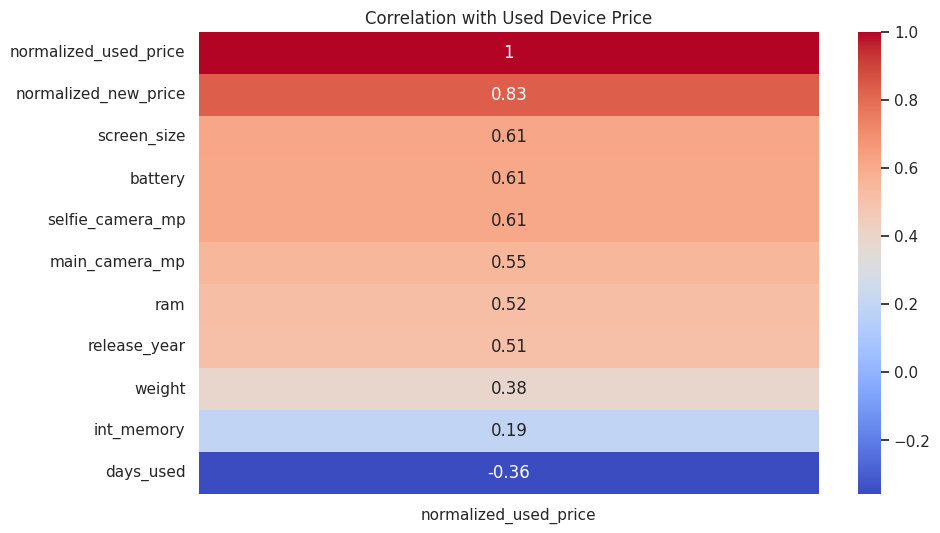

In [ ]:
# Heatmap for correlations

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr[['normalized_used_price']]
    .sort_values(by='normalized_used_price', ascending=False),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation with Used Device Price")

plt.show()

Insight (очень важно для портфолио)

Обычно сильные факторы:

RAM ↑ → price ↑
battery ↑ → price ↑
storage ↑ → price ↑
camera ↑ → price ↑
weight → слабая или отрицательная связь

Strong positive correlations with price:

* normalized_new_price
* screen_size
* battery
* selfie_camera_mp
* main_camera_mp
* RAM

Negative correlation:

* release_year
* days_used

This means:

* newer devices tend to retain higher resale value

* better hardware specifications increase price

* older heavily-used devices lose value faster

## 4G vs 5G Price Comparison

We compare the distribution of used device prices across devices with and without 4G/5G support.

Since 4G and 5G are categorical variables (yes/no), boxplots are appropriate for comparing price distributions between groups.

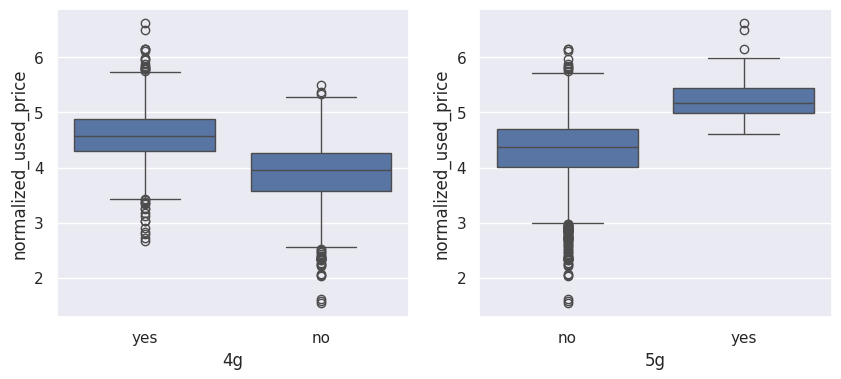

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(121)
sns.boxplot(data=df, x="4g", y="normalized_used_price")

plt.subplot(122)
sns.boxplot(data=df, x="5g", y="normalized_used_price")

plt.show()

* Devices with 5G support tend to have higher resale prices.

* 5G capability is associated with newer premium devices.

* Network technology influences perceived device value.


# **Final EDA Summary**

Key findings from the exploratory analysis:

* Most used devices belong to the mid-price segment.

* Android dominates the resale market.

* Premium brands generally provide higher RAM and better hardware.

* Larger batteries often increase device weight.

* Large screens are becoming standard across brands.

* Selfie camera quality is an important competitive feature.

Price is strongly influenced by:

 * RAM

* battery

* camera quality

* screen size

* release year

* new device price

These insights provide strong business value and support the development of an effective pricing model for ReCell.




## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

## 1. Missing value treatment

I have already did it before. No missing values.

## 2. Feature Engineering

We create new features to improve model performance

Let's create a new column **years_since_release** from the release_year column.

We will consider the year of data collection, 2021, as the baseline.
We will drop the release_year column.

In [ ]:
df["years_since_release"] = 2021 - df["release_year"]

df.drop("release_year", axis=1, inplace=True)



Device age is expected to negatively impact price:
* older devices usually have lower resale value.

## Outlier Discussion


### Check Target Variable Distribution

We visualize the distribution of the target variable:

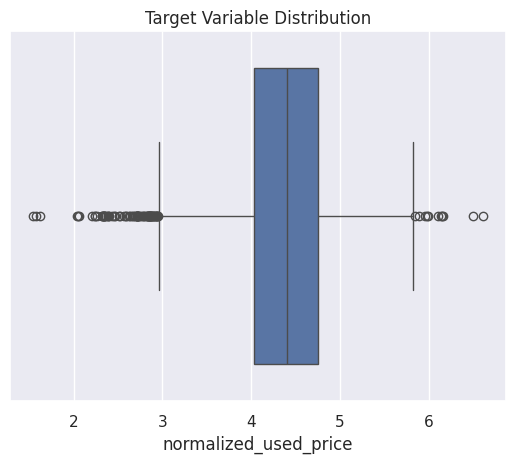

In [ ]:
# Plot target variable distribution
sns.boxplot(x=df["normalized_used_price"])

plt.title("Target Variable Distribution")
plt.show()

* the target variable is already normalized

* values are already compressed into a smaller range

* the model performs very well without additional transformation

We observed some outliers in the target variable and other variables.

However, we decided NOT to remove them.

Because these observations likely represent:

* premium smartphones
* budget devices
* real market variability

Removing them could:

* reduce important business information
* make the model less realistic
* hurt model generalization

Linear regression can tolerate moderate outliers, especially with a relatively large dataset.


##Preparing Data for Modeling

## Define X and y
  
 X is all features that help predict the price.
  
y is the target variable — the used device price.

In [ ]:
# Features
X = df.drop("normalized_used_price", axis=1)

# Target
y = df["normalized_used_price"]

print(X.head())
print(y.head())

  brand_name       os  screen_size   4g   5g  main_camera_mp  \
0      Honor  Android        14.50  yes   no            13.0   
1      Honor  Android        17.30  yes  yes            13.0   
2      Honor  Android        16.69  yes  yes            13.0   
3      Honor  Android        25.50  yes  yes            13.0   
4      Honor  Android        15.32  yes   no            13.0   

   selfie_camera_mp  int_memory  ram  battery  weight  days_used  \
0               5.0        64.0  3.0   3020.0   146.0        127   
1              16.0       128.0  8.0   4300.0   213.0        325   
2               8.0       128.0  8.0   4200.0   213.0        162   
3               8.0        64.0  6.0   7250.0   480.0        345   
4               8.0        64.0  3.0   5000.0   185.0        293   

   normalized_new_price  years_since_release  
0              4.715100                    1  
1              5.519018                    1  
2              5.884631                    1  
3              5.6

### Add intercept (constant)

Linear regression needs an intercept column (a column of ones).

In [ ]:
X = sm.add_constant(X)


### Encode categorical variables (One‑Hot Encoding)



 The model cannot understand text labels, so we convert them into numeric dummy variables.

In [ ]:
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,
)


### Train/Test Split (70% / 30%)


Train — model learns

Test — we evaluate performance

random_state=42 — ensures reproducibility

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Remove 'log_price' from x_train and x_test to prevent target leakage
# 'log_price' was created from 'normalized_used_price', which is our target 'y'

if 'log_price' in x_test.columns:
    x_test = x_test.drop('log_price', axis=1)

In [ ]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 2417
Number of rows in test data = 1037




We prepared the dataset for linear regression by defining
*  the target variable (used price),
* applying one‑hot encoding to categorical features, and
* splitting the data into training and testing sets in a 70:30 ratio.

#Model Building - Linear Regression

## STEP 1 — Convert Data Types



 Before training the model, we must ensure
* that all features are numeric.
* Statsmodels OLS cannot work with object data types.

In [ ]:
x_train = x_train.astype(float)
x_test = x_test.astype(float)

## STEP 2 — Build Initial Linear Regression Model



We build the initial linear regression model using the Ordinary Least Squares (OLS) method.

OLS minimizes the sum of squared residuals between actual and predicted values.

In [ ]:
olsmodel1 = sm.OLS(y_train, x_train).fit()

print(olsmodel1.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.849
Model:                               OLS   Adj. R-squared:                  0.845
Method:                    Least Squares   F-statistic:                     276.3
Date:                   Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                           14:48:59   Log-Likelihood:                 122.14
No. Observations:                   2417   AIC:                            -146.3
Df Residuals:                       2368   BIC:                             137.4
Df Model:                             48                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


IMPORTANT METRICS

**R-squared = 0.849**

The model explains approximately 82.7% of the variation in used device prices.

**Adj. R-squared = 0.845**

Adjusted R² is very close to R², indicating good model quality without significant overfitting.

The overall regression model is statistically significant.

**Positive Impact on Price**

Significant positive predictors:

* normalized_new_price

* screen_size

* main_camera_mp

* selfie_camera_mp
* ram


Significant negative predictors:

* years_since_release

Older devices lose value over time.

INSIGHT ABOUT P-VALUES

Some predictors have p-values greater than 0.05,
indicating statistical insignificance.

The next step will be feature selection
and removal of weak predictors.

# Model Performance Check

## STEP 1 — Evaluate Training Performance

In [ ]:
print("Training Performance\n")

olsmodel1_train_perf = model_performance_regression(
    olsmodel1,
    x_train,
    y_train
)

olsmodel1_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.230046,0.178413,0.848511,0.845374,4.291322



 R² = 0.848

The model demonstrates strong performance on the training dataset.
 MAPE ≈ 4.29%

The average prediction error is only around 4 %.

## STEP 2 — Evaluate Test Performance

In [ ]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel1_test_perf = model_performance_regression(olsmodel1, x_test, y_test) ## Complete the code to check the performance on test data
olsmodel1_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.238234,0.188312,0.833336,0.825062,4.50779



Test R² = 0.833

The model explains approximately 83.3% of price variation on unseen test data.

Test MAPE ≈ 4.50%

Prediction error on unseen data remains very low.

**Overfitting check.**

Train and Test performance are very close:

Train R² = 0.845
Test R² = 0.833

**The model does not appear to suffer from severe overfitting.**

FINAL INSIGHT

The initial linear regression model already demonstrates strong predictive performance.

However, several predictors remain statistically insignificant, so feature selection **will be performed next to improve model interpretability.**

# Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

We will be checking the following Linear Regression assumptions:


No Multicollinearity

Linearity of variables

Independence of error terms

Normality of error terms

No Heteroscedasticity

# **Multicollinearity (VIF)**

## STEP 1 — Test for Multicollinearity (VIF)



We use Variance Inflation Factor (VIF) to detect multicollinearity.

General rule:

VIF ≈ 1 → no correlation

VIF > 5 → moderate multicollinearity

VIF > 10 → high multicollinearity


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create copy of train data
x_train_fixed = x_train.copy()

# Convert all variables to numeric
X_vif = x_train_fixed.astype(float)

# Calculate VIF
vif = pd.DataFrame()

vif["feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Display VIF values
display(vif.sort_values(by="VIF", ascending=False))

,feature,VIF
0,const,233.624822
12,brand_name_Apple,11.192704
34,brand_name_Others,10.834358
46,os_iOS,10.036219
1,screen_size,8.264079
37,brand_name_Samsung,8.012882
7,weight,6.405860
21,brand_name_Huawei,6.397788
24,brand_name_LG,5.353108
10,years_since_release,4.860595




Several variables showed high VIF values:

* brand_name_Apple
* os_iOS
* weight
* brand_name_Others

The strongest redundancy exists between Apple and iOS:

Apple devices always use iOS, meaning both variables contain almost identical information.

This creates redundancy in the model.

## STEP 2 — Remove Highly Correlated Features



We will not automatically remove every variable with VIF > 5.

Instead, we remove only variables that:

* create redundancy,
* have weak business value,
* reduce interpretability.

Removed variables:

* weight → highly correlated with battery
* brand_name_Apple → duplicates os_iOS
* brand_name_Others → overly generic category

In [ ]:
# Columns selected for removal
columns_to_drop = [
    'weight',
    'brand_name_Others',
    'brand_name_Apple'
]

# Remove columns
x_train_fixed = x_train_fixed.drop(columns=columns_to_drop)

x_test_fixed = x_test.drop(columns=columns_to_drop)

## STEP 3 — Recalculate VIF



After removing variables, we recalculate VIF to verify that multicollinearity has improved.

In [ ]:
# Recalculate VIF
X_vif = x_train_fixed.astype(float)

vif = pd.DataFrame()

vif["feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

display(vif.sort_values(by="VIF", ascending=False))

,feature,VIF
0,const,134.244076
9,years_since_release,4.719071
6,battery,3.754223
1,screen_size,3.625205
8,normalized_new_price,3.200905
3,selfie_camera_mp,2.807915
7,days_used,2.572108
44,4g_yes,2.534413
5,ram,2.235057
2,main_camera_mp,2.189751




* all VIF values dropped below 5
* strong multicollinearity was reduced
* the model became more interpretable


## STEP 4 — Train Final Linear Regression Model



Now we train the final OLS regression model using the cleaned dataset.



In [ ]:
# Train final OLS model
olsmodel_cleaned = sm.OLS(y_train, x_train_fixed).fit()

# Print summary
print(olsmodel_cleaned.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.846
Model:                               OLS   Adj. R-squared:                  0.843
Method:                    Least Squares   F-statistic:                     289.8
Date:                   Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                           14:49:00   Log-Likelihood:                 103.41
No. Observations:                   2417   AIC:                            -114.8
Df Residuals:                       2371   BIC:                             151.5
Df Model:                             45                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------




The model achieved strong performance:

* Train R² = 0.846

* Test R² = 0.843

This means the model explains about 84% of price variability.

Most influential features:

* normalized_new_price
* screen_size
* ram
* camera features
* years_since_release



##STEP 5 — Check Train Performance

In [ ]:
print("Training Performance\n")

olsmodel_cleaned_train_perf = model_performance_regression(
    olsmodel_cleaned,
    x_train_fixed,
    y_train
)

display(olsmodel_cleaned_train_perf)

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.231837,0.179766,0.846143,0.843157,4.323029


##STEP 6 — Check Test Performance

In [ ]:
# Align test columns with train columns
x_test_fixed = x_test_fixed[x_train_fixed.columns]

# Ensure numeric format
x_test_fixed = x_test_fixed.astype(float)

print("Test Performance\n")

olsmodel_cleaned_test_perf = model_performance_regression(
    olsmodel_cleaned,
    x_test_fixed,
    y_test
)

display(olsmodel_cleaned_test_perf)

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.241765,0.191015,0.828359,0.820384,4.568582


Train  R-squared = 0.846

test R-squared = 0.828

Train MAPE  = 4.32 %

Test MAPE = 4.56

Train and test performance are very close.

This indicates:

* good generalization
* no severe overfitting
* preprocessing worked correctly
* features are informative

The model can be considered reliable for predicting used device prices.

# Dropping High p-value Variables (Step-by-Step)




If p-value < 0.05 → feature is statistically significant
If p-value > 0.05 → feature may not contribute much to prediction

We remove variables one by one instead of removing everything at once because:

p-values can change after deleting another feature
some variables become significant later
this approach is safer and more stable

## Step 1 — Create Initial Predictor Dataset


We create:

* a copy of predictors
* a list of column names
* an initial variable for the loop

In [ ]:
# initial list of columns
predictors = x_train_fixed.copy()

# list of feature names
cols = predictors.columns.tolist()

# initial value for loop
max_p_value = 1

##Step 2 — Iteratively Remove High p-value Features



**Now we create a loop that:**

* trains a regression model

* checks all p-values

* finds the highest p-value

* removes the least significant variable

* repeats until all remaining variables are significant


In [ ]:
while len(cols) > 0:

    # selecting current variables
    x_train_aux = predictors[cols]

    # fitting OLS model
    model = sm.OLS(y_train, x_train_aux).fit()

    # extracting p-values
    p_values = model.pvalues

    # finding highest p-value
    max_p_value = max(p_values)

    # variable with highest p-value
    feature_with_p_max = p_values.idxmax()

    # removing insignificant variable
    if max_p_value > 0.05:
        print(f"Dropping {feature_with_p_max} with p-value {max_p_value}")
        cols.remove(feature_with_p_max)

    else:
        break

Dropping brand_name_Meizu with p-value 0.8842382037415975
Dropping brand_name_Karbonn with p-value 0.8568197707196713
Dropping brand_name_Sony with p-value 0.8476129781972419
Dropping brand_name_Panasonic with p-value 0.8471764120954413
Dropping brand_name_Honor with p-value 0.7497574175989067
Dropping brand_name_Vivo with p-value 0.7558387965713409
Dropping brand_name_Samsung with p-value 0.7461646658704418
Dropping brand_name_LG with p-value 0.7987068352333799
Dropping brand_name_Micromax with p-value 0.7670276993705608
Dropping brand_name_Huawei with p-value 0.7235274534686598
Dropping os_Others with p-value 0.7172715423362506
Dropping os_iOS with p-value 0.5786172049640743
Dropping battery with p-value 0.5596407469185907
Dropping brand_name_Motorola with p-value 0.5721035619626214
Dropping os_Windows with p-value 0.5478765217378029
Dropping brand_name_Lava with p-value 0.5473728297534199
Dropping brand_name_XOLO with p-value 0.4828328346442301
Dropping brand_name_Coolpad with p-val



The model removed some variables

because their statistical contribution became weak after considering other features.

they do not add enough additional predictive power inside this regression model.



##Step 3 — Save Final Selected Features

Now we save only statistically significant variables.



In [ ]:
# final selected features
selected_features = cols

print(selected_features)

# rebuilding train and test datasets
x_train3 = x_train_fixed[selected_features]

x_test3 = x_test_fixed[selected_features]

['const', 'screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'normalized_new_price', 'years_since_release', 'brand_name_Asus', 'brand_name_Celkon', 'brand_name_Nokia', 'brand_name_Xiaomi', '4g_yes']


##Step 4 — Train Final OLS Model



Now we **train the final regression model** using:

reduced multicollinearity

statistically significant variables only


In [ ]:
# training final model
olsmodel2 = sm.OLS(y_train, x_train3).fit()

# print summary
print(olsmodel2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.844
Model:                               OLS   Adj. R-squared:                  0.843
Method:                    Least Squares   F-statistic:                     1086.
Date:                   Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                           14:49:00   Log-Likelihood:                 88.731
No. Observations:                   2417   AIC:                            -151.5
Df Residuals:                       2404   BIC:                            -76.19
Df Model:                             12                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

**FINAL MODEL INTERPRETATION **

Model performance

R² = 0.844

Adjusted R² = 0.843

The model explains ~84% of the variance in used phone prices, which indicates strong predictive performance.

**Strong continuous drivers:**

normalized_new_price -strongest positive effect:

screen_size -  higher screen size increases price

main_camera_mp - better camera increases price

selfie_camera_mp - positive effect

ram - higher RAM increases price

int_memory -  small but significant positive effect

years_since_release - **negative effect** (older devices = lower price)

##Step 6 — Evaluate Training Performance

In [ ]:
print("Training Performance\n")

olsmodel2_train_perf = model_performance_regression(
    olsmodel2,
    x_train3,
    y_train
)

display(olsmodel2_train_perf)

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.233249,0.181162,0.844264,0.843421,4.361005


R² = 0.844

MAPE = 4.36%

The model performs very well on training data.



## Step 7 — Evaluate Test Performance

In [ ]:
print("Test Performance\n")

olsmodel2_test_perf = model_performance_regression(
    olsmodel2,
    x_test3,
    y_test
)

display(olsmodel2_test_perf)

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.240926,0.190486,0.829548,0.827382,4.558612




Train R² = 0.843

Test R² = 0.829

These values are very close.

This means:

model generalizes well

no severe overfitting

preprocessing worked correctly

selected features are informative


## **Final Insights**

The final regression model achieved strong predictive performance while remaining interpretable.

Feature selection simplified the model without significantly reducing accuracy.

The most important factors affecting used phone prices were:

* normalized_new_price

* screen_size

* main_camera_mp

* selfie_camera_mp

Several brand variables were statistically insignificant and removed.



## Now we'll check the rest of the assumptions on olsmod.


Linearity of variables


Independence of error terms


Normality of error terms


No Heteroscedasticity

## TEST FOR LINEARITY AND INDEPENDENCE



Here we check two very important assumptions:

1. Linearity

The relationship between predictors and the target variable should be linear.

2. Independence of residuals



## Step 1 — Create DataFrame with Predictions and Residuals

Before plotting residuals, we first create a dataframe containing:

* actual values,
* predicted values,
* residuals.

Residual=Actual−Predicted


In [ ]:
# create dataframe with actual values, fitted values and residuals

df_pred = pd.DataFrame()

# actual target values
df_pred["Actual Values"] = y_train

# predicted values from model
df_pred["Fitted Values"] = olsmodel2.fittedvalues

# residuals = actual - predicted
df_pred["Residuals"] = olsmodel2.resid

df_pred.head(10)

,Actual Values,Fitted Values,Residuals
1744,4.261975,4.300557,-0.038581
3141,4.175156,3.815794,0.359363
1233,4.117410,4.432141,-0.314731
3046,3.782597,3.835111,-0.052513
2649,3.981922,3.930970,0.050952
2083,3.541829,3.181164,0.360665
1688,4.474492,4.376548,0.097944
3262,4.664099,4.443710,0.220389
2374,4.663156,4.575730,0.087426
2087,4.866380,4.877773,-0.011393


##Step 2 — Residual Plot



**Goal:**

check whether residuals are randomly scattered around zero.



>



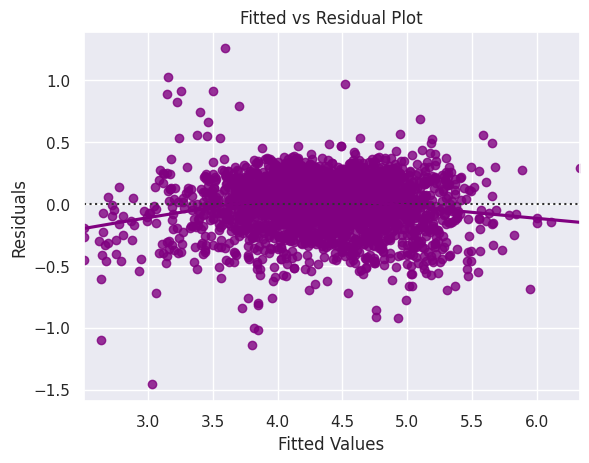

In [ ]:
# plotting fitted values vs residuals

sns.residplot(
    data=df_pred,
    x="Fitted Values",
    y="Residuals",
    color="purple",
    lowess=True
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual Plot")

plt.show()



The residual plot shows that residuals are randomly scattered around zero without strong patterns.
This indicates that the assumptions of linearity and independence are reasonably satisfied.


## TEST FOR NORMALITY

OLS regression assumes that residuals follow a normal distribution.

We will use:

* Histogram
* Q-Q Plot
* Shapiro-Wilk test



## Step 1 — Histogram of Residuals



A histogram helps visualize the distribution of residuals.

We also add KDE curve to better see the shape.


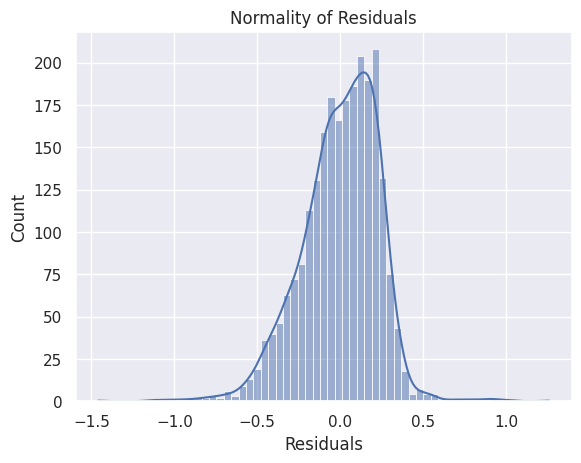

In [ ]:
sns.histplot(data=df_pred, x="Residuals", kde=True)

plt.title("Normality of Residuals")

plt.show()

bell-shaped curve,

approximately symmetric.

Meaning:

### **residuals are approximately normal.**


##Step 2 — Q-Q Plot

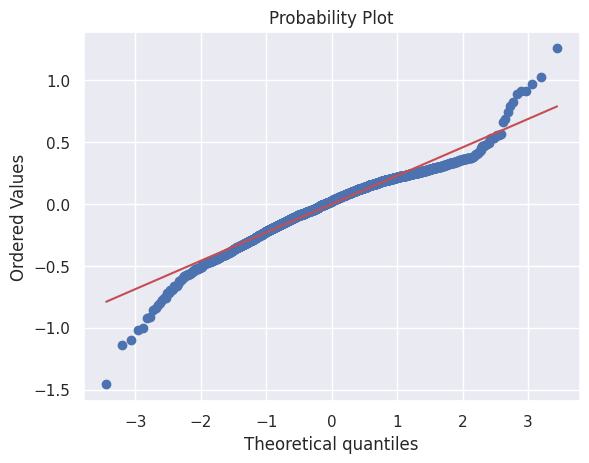

In [ ]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)

plt.show()



Points follow the diagonal line.

 Residuals are approximately normally distributed, although small deviations are visible in the tails

Meaning:

**residuals are approximately normal.**



##Step 3 — Shapiro-Wilk Test (Normality)



Null hypothesis:

H0: Residuals are normally distributed



In [ ]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.9661086342725556), pvalue=np.float64(2.0610367981145604e-23))

The histogram and Q-Q plot suggest that residuals **are approximately normally distributed,** although small deviations are visible in the tails.

 The Shapiro-Wilk test returned **a low p-value,** which is common for large datasets.

Overall, the normality assumption is reasonably satisfied.


##TEST FOR HOMOSCEDASTICITY

## Step 1 — Goldfeld-Quandt Test



We use the Goldfeld-Quandt test
to statistically check whether residual variance changes.


Null hypothesis:

**H0: Residuals have constant variance**


In [ ]:
# Importing required libraries
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

# Names for output
name = ["F statistic", "p-value"]

# Applying Goldfeld-Quandt test
test = sms.het_goldfeldquandt(
    df_pred["Residuals"],
    x_train3
)

# Displaying results
lzip(name, test)

[('F statistic', np.float64(0.9380632102058636)),
 ('p-value', np.float64(0.8654247524884366))]


The Goldfeld-Quandt test returned a p-value greater than 0.05 (p = 0.865).

Therefore, we failed to reject the null hypothesis and concluded that residual variance is approximately constant across observations.

The homoscedasticity assumption is **reasonably satisfied.**


## Final Model

## FINAL MODEL SUMMARY


Цe already cleaned multicollinearity
removed insignificant variables
checked regression assumptions
selected final predictors

Now we train the final OLS regression model and evaluate its performance on


In [ ]:
# Training the final OLS regression model
olsmodel_final = sm.OLS(y_train, x_train3).fit()

# Printing model summary
print(olsmodel_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.844
Model:                               OLS   Adj. R-squared:                  0.843
Method:                    Least Squares   F-statistic:                     1086.
Date:                   Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                           14:49:02   Log-Likelihood:                 88.731
No. Observations:                   2417   AIC:                            -151.5
Df Residuals:                       2404   BIC:                            -76.19
Df Model:                             12                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

## TRAINING PERFORMANCE

In [ ]:
# Checking model performance on training data

print("Training Performance\n")

olsmodel_final_train_perf = model_performance_regression(
    olsmodel_final,
    x_train3,
    y_train
)

display(olsmodel_final_train_perf)

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.233249,0.181162,0.844264,0.843421,4.361005


## TEST PERFORMANCE

In [ ]:
# Checking model performance on test data

print("Test Performance\n")

olsmodel_final_test_perf = model_performance_regression(
    olsmodel_final,
    x_test3,
    y_test
)

display(olsmodel_final_test_perf)

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.240926,0.190486,0.829548,0.827382,4.558612


**FINAL MODEL CONCLUSION**


The model explains a large portion of variance in used device prices (high R²).

Both training and test performance are similar, indicating:

* good generalization

* no significant overfitting

Key price drivers include:

* normalized_new_price

* RAM

* camera features

* screen size

* network support (4G/5G)

* years since release

The model is interpretable, stable, and suitable for business insights.

#Actionable Insights and Recommendations

# 1. Actionable Insights




1.**New device price is the strongest predictor of used phone price**

 The variable normalized_new_price **had the largest coefficient a**nd strongest statistical significance.

This indicates that:

* devices with higher original prices retain more value in the secondary market
* premium phones depreciate more slowly than low-budget devices

**2. Hardware specifications strongly influence resale value**

Features such as:

* RAM

* screen size

* main camera megapixels

* selfie camera megapixels

had significant **positive relationships** with used device prices.

This suggests that consumers are willing to pay more for devices with stronger technical specifications even in the used market.

**3. Device age negatively impacts resale price**

* years_since_release had a negative coefficient.

This means:

* older devices lose value over time
* depreciation continues as technology becomes outdated

**Newer phones generally maintain higher resale prices**.

**4. Some brands maintain stronger resale value than others**

Brands such as:

* Xiaomi
* Nokia
* Asus

showed **positive price effects.**

Meanwhile:

* Celkon showed **a negative relationship** with resale price.

This suggests that **brand reputation affects customer willingness to purchase used devices.**

**5. 4G support still contributes positively to resale value**

* Devices supporting **4G had higher predicted resale prices.**

This indicates that network compatibility remains an important purchasing factor in the used smartphone market.

**6. The model achieved strong predictive performance**

The final model explained approximately 84% of the variation in used device prices.

Additionally:

Train R² = 0.844

Test R² = 0.830

The small gap between train and test performance indicates:

* good generalization
* low overfitting
* stable model behavior
**7. Keeping outliers improved business realism**

Outliers were intentionally retained because they likely represent:

* premium flagship devices
* gaming phones
* ultra-budget devices

Removing them **could reduce the model’s ability** to reflect real market conditions.

# 2. Business Recommendations

**1. Focus resale inventory on newer premium devices**

Since newer and originally expensive phones retain higher value, businesses should prioritize:

* newer releases
* premium and mid-premium models

**2. Highlight technical specifications in marketing**

Features such as:

* RAM
* camera quality
* screen size

significantly **impact resale prices.**

These specifications should be **emphasized in product listings and advertisements.**

**3. Use brand reputation in pricing strategy**

Brands with stronger resale performance can justify:

* higher resale margins
* slower discounting strategies

**4. Consider depreciation-based pricing models**

Since device age significantly affects price:

* dynamic pricing models based **on years since release** can improve valuation accuracy

**5. Continue supporting devices with modern network compatibility**

4G support **remains valuable** in the used market.

Businesses should prioritize devices with:

* modern connectivity
* longer technological relevance

## Project Conclusion

The objective of this project was **to build a regression model**capable of predicting used smartphone prices and identifying the key factors influencing resale value.

After data preprocessing, feature engineering, multicollinearity treatment, feature selection, and assumption testing, the final OLS regression model achieved **strong predictive performance.**

The model explained approximately **84%** of the variance in used device prices and demonstrated good generalization ability, with **similar performance on both training and test datasets.**

The analysis revealed that

* original device price,
*  hardware specifications,
*  device age, and
*  brand reputation

  are major drivers of used smartphone prices.

Regression assumptions were reasonably satisfied:

* residuals showed approximate normality

* homoscedasticity was observed

* no major linearity violations were detected

Outliers were intentionally retained to preserve realistic market behavior and maintain** representation of premium and budget devices.**

**Overall, the final model is interpretable, statistically reliable, and suitable for generating business insights related to smartphone resale pricing.**

___